# Notebook E of more line ratios from saved maps from the PZ cubes

This is adapted from 01-02-yet-more-line-ratios. It includes the [S II] density


In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from mpdaf.obj import Image
from zz_utils import get_image_raw, ROOT
import regions
import sys
import pandas as pd
import cmasher as cmr
import pyneb as pn

sns.set_context("talk")
sns.set_color_codes()

/Users/will/Dropbox/muse-hii-regions/.venv/lib/python3.14/site-packages/mpdaf/version.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
def trim_edges(im, m):
    """Trim m pixels of each edge of image in place by setting mask"""
    im.mask[:m, :] = True
    im.mask[-m:, :] = True
    im.mask[:, :m] = True
    im.mask[:, -m:] = True
    return None

In [3]:
datadir = ROOT / "data"
figdir = ROOT / "figs"

Read in the [S II] lines and the Ha line, together with the continuum at the 6716 line

In [12]:
im6716 = get_image_raw("s-ii-671*")
im6731 = get_image_raw("s-ii-673*")
imha = get_image_raw("h-i-656*")
imcont = get_image_raw("s-ii-671*", variant="cont")
imha, imcont

(<Image(shape=(326, 346), unit='', dtype='float64')>,
 <Image(shape=(326, 346), unit='', dtype='float64')>)

Calculate the 6716 equivalent width in Angstrom

In [16]:
ew6716 = 3 * 1.25 * im6716 / imcont 

Look at the equivalent width. It seems that 1 AA is a good threshold

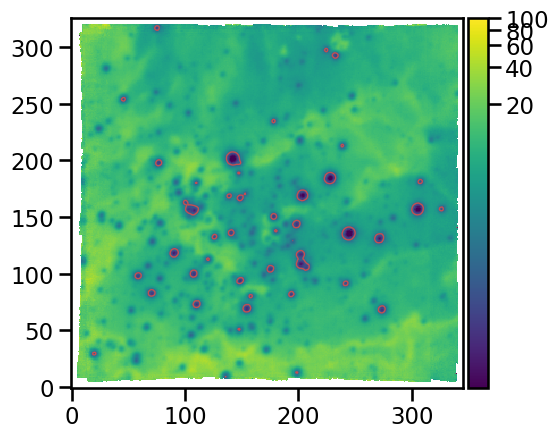

In [39]:
fig, ax = plt.subplots()
ew6716.plot(colorbar="v", scale="log", vmin=0.1, vmax=100)
ax.contour(ew6716.data, levels=[1.0], linewidths=1, colors="r")

In [13]:
s2 = pn.Atom("S", 2)
e6716 = s2.getEmissivity(tem=13000, den=[3, 10, 30, 100, 300, 1000], wave=6716)
e6731 = s2.getEmissivity(tem=13000, den=[3, 10, 30, 100, 300, 1000], wave=6731)
Rgrid = e6716 / e6731
Rgrid

array([1.43878982, 1.43185268, 1.4125499 , 1.35049829, 1.20992   ,
       0.93887822])

Trim off the edges that have elevated noise levels

In [40]:
trim_edges(im6716, 10)
trim_edges(im6731, 10)
trim_edges(imcont, 10)

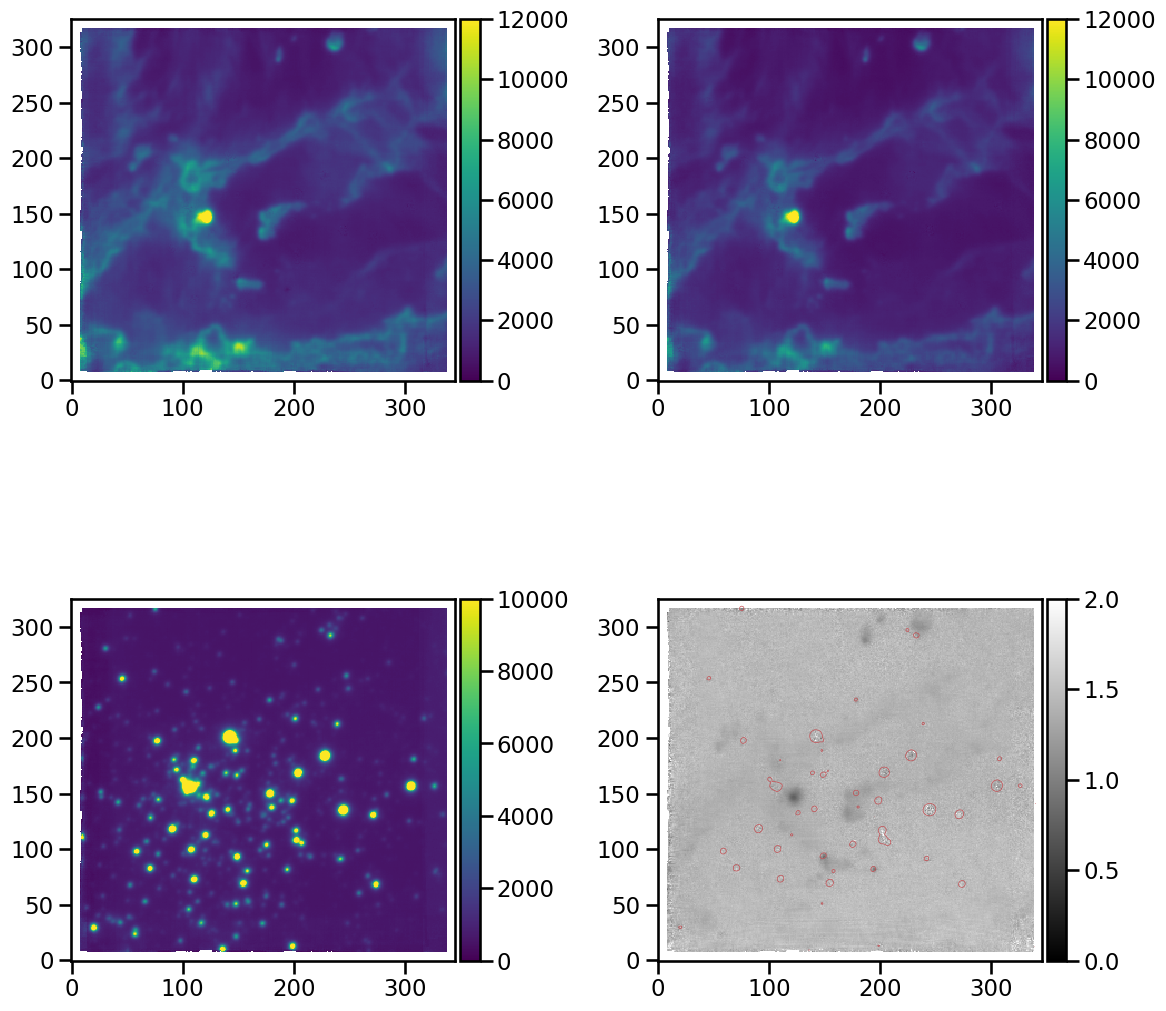

In [36]:
n = 1
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
im6716.rebin(n).plot(vmin=-10, vmax=12000, ax=axes[0, 0], colorbar="v")
im6731.rebin(n).plot(vmin=-10, vmax=12000, ax=axes[0, 1], colorbar="v")
imcont.rebin(n).plot(vmin=0, vmax=1e4, ax=axes[1, 0], colorbar="v")
(im6716.rebin(n) / im6731.rebin(n)).plot(
    ax=axes[1, 1],
    vmin=0.0,
    vmax=2.0,
    cmap="gray",
    colorbar="v",
)
axes[1, 1].contour(ew6716.data, levels=[1.0], linewidths=0.5, colors="r")
fig.tight_layout()

So the regions with EW < 1 AA have elvated noise in the sii ratio and maybe should be masked out

Text(0.5, 0.98, 'Correlation between [S II] 6731 and 6716 brightness')

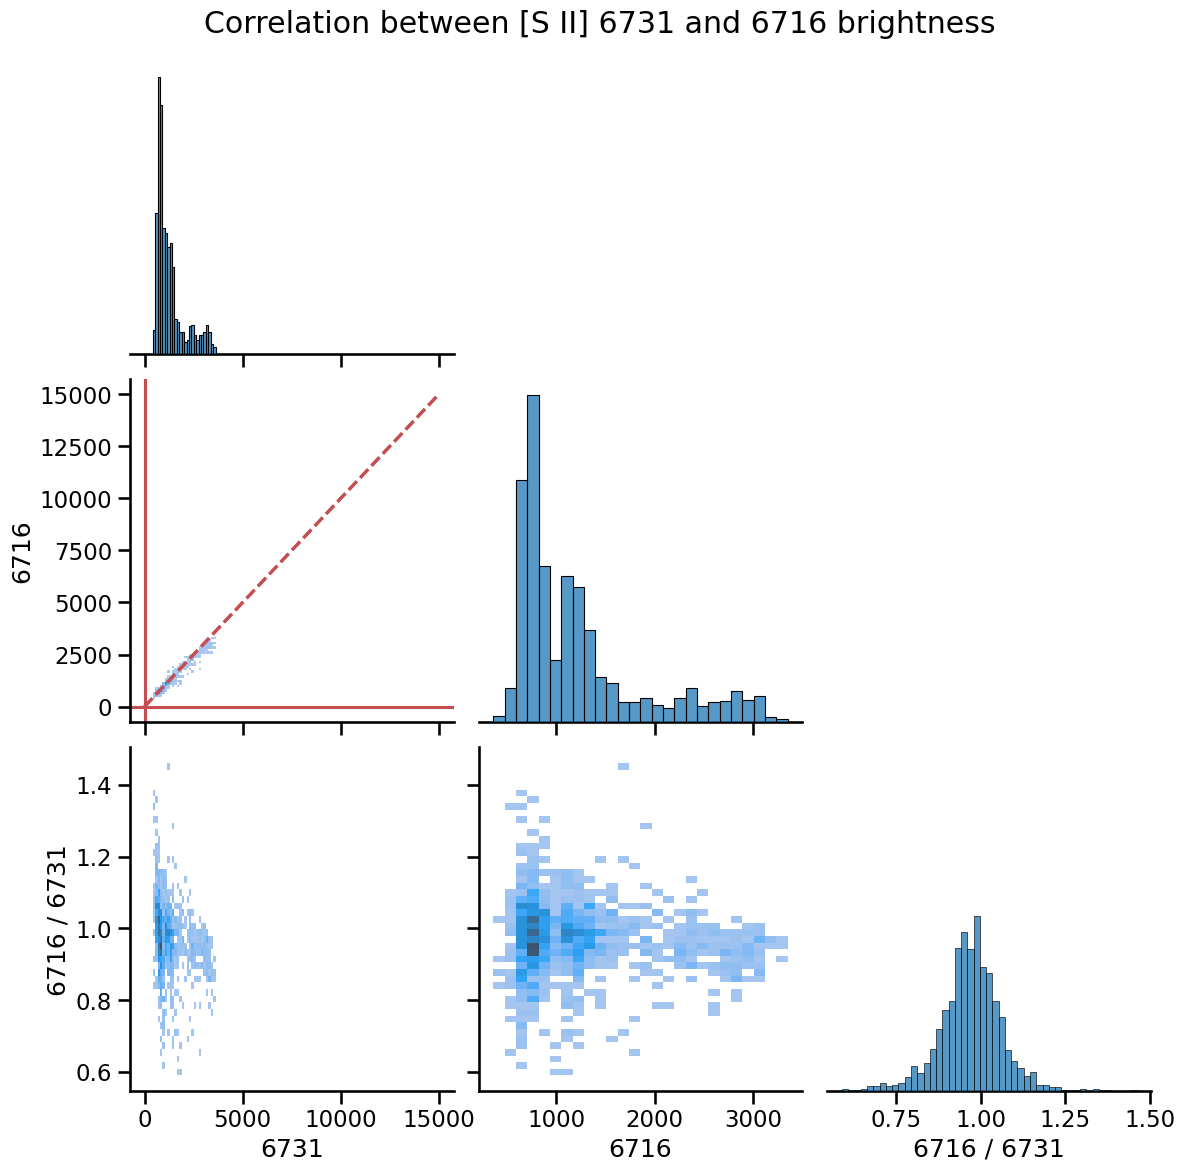

In [45]:
n = 1

imx = im6731.rebin(n)
imy = (im6716 / 1.44).rebin(n)

imin, imax = -10, 15000
# m = (imx.data < imax) & (imy.data < imax)
# m = m & (imx.data > imin) & (imy.data > imin)
# m = m & (imy.data / imx.data > 0.5) & (imy.data / imx.data < 1.5)
m = m & ~imx.mask & ~imy.mask
# Mask out low EW
m &= ew6716.rebin(n).data < 1.0
df = pd.DataFrame(
    {
        "6731": imx.data[m],
        "6716": imy.data[m],
        "6716 / 6731": imy.data[m] / imx.data[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
)
g.axes[1, 0].axvline(0.0, color="r")
g.axes[1, 0].axhline(0.0, color="r")
g.axes[1, 0].plot([imin, imax], [imin, imax], "--", color="r")
g.axes[1, 0].plot([imin, imax], [imin, imax], "--", color="r")
g.fig.suptitle("Correlation between [S II] 6731 and 6716 brightness")

Text(0.5, 0.98, 'Correlation between [S II] 6716 / 6731 sum and Ha brightness')

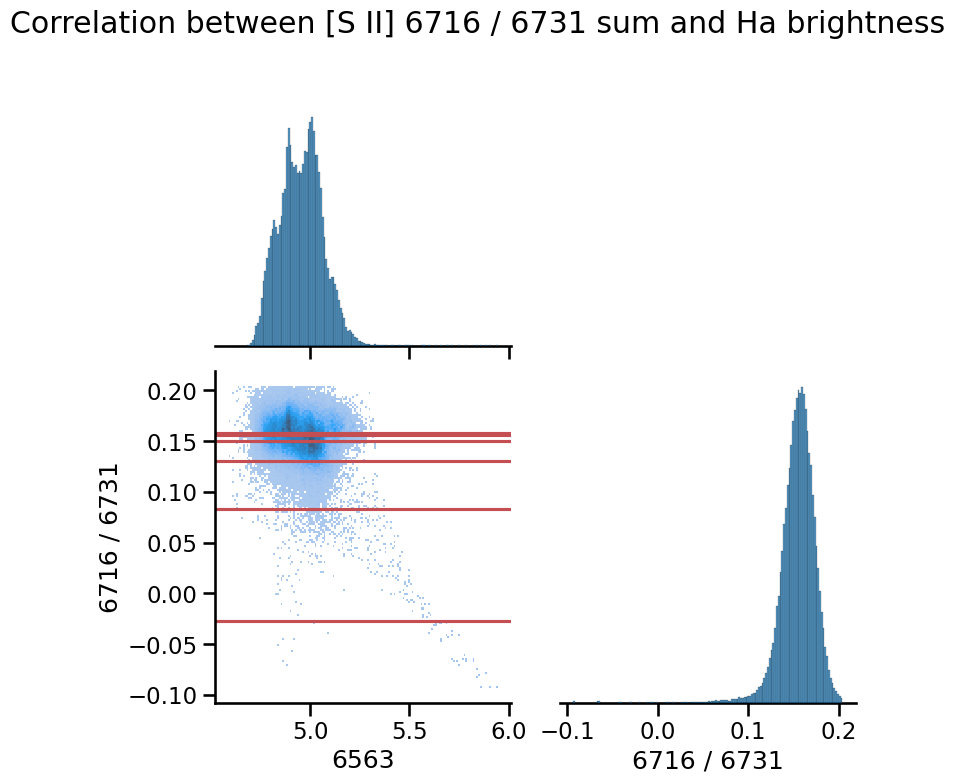

In [46]:
n = 1
imx = imha.rebin(n)
imy = im6716.rebin(n) / im6731.rebin(n)

m = (imy.data > 0.8) & (imy.data < 1.6)
m = m & (imx.data < 1.5e6)
m = m & ~imx.mask & ~imy.mask
df = pd.DataFrame(
    {
        "6563": np.log10(imx.data[m]),
        "6716 / 6731": np.log10(imy.data[m]),
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(
        weights=imx.data[m],
        bins=150,
    ),
    diag_kws=dict(
        weights=imx.data[m],
        bins=150,
    ),
)
for R in Rgrid:
    g.axes[1, 0].axhline(np.log10(R), color="r")
g.fig.suptitle("Correlation between [S II] 6716 / 6731 sum and Ha brightness")

Text(0.5, 0.98, 'Correlation between [S II] 6716 / 6731 sum and Ha brightness')

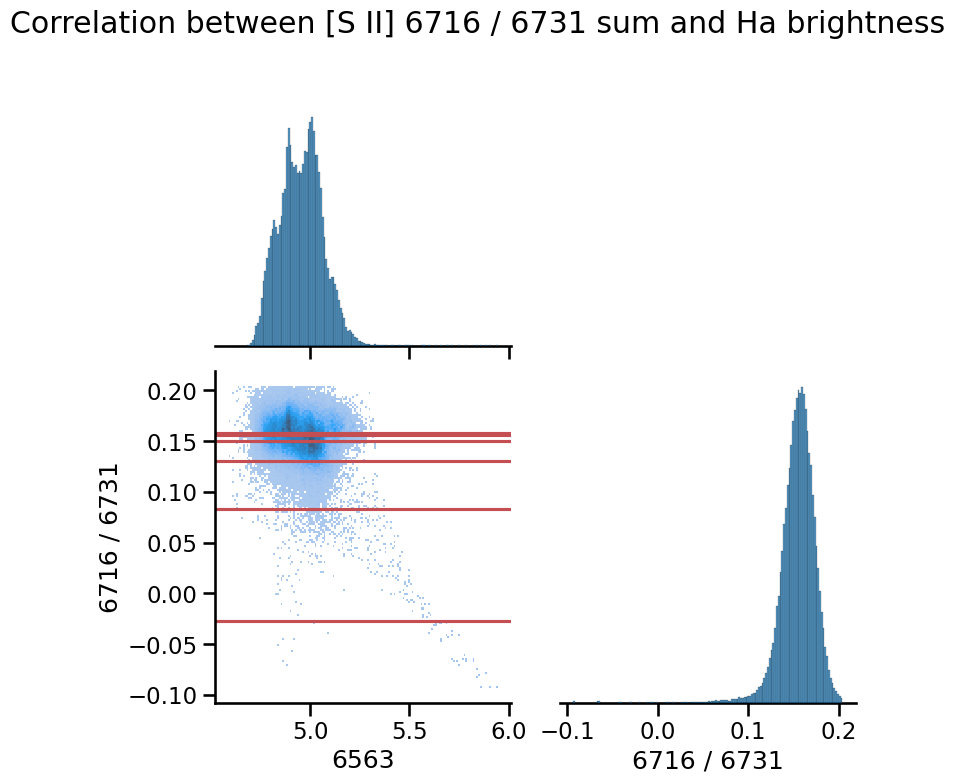

In [47]:
n = 1
imx = imha.rebin(n)
imy = im6716.rebin(n) / im6731.rebin(n)

m = (imy.data > 0.8) & (imy.data < 1.6)
m = m & (imx.data < 1.5e6)
m = m & ~imx.mask & ~imy.mask
df = pd.DataFrame(
    {
        "6563": np.log10(imx.data[m]),
        "6716 / 6731": np.log10(imy.data[m]),
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(
        weights=imx.data[m],
        bins=150,
    ),
    diag_kws=dict(
        weights=imx.data[m],
        bins=150,
    ),
)
for R in Rgrid:
    g.axes[1, 0].axhline(np.log10(R), color="r")
g.fig.suptitle("Correlation between [S II] 6716 / 6731 sum and Ha brightness")

Text(0.5, 0.98, 'Correlation between [S II] 6716 / 6731 ratio and Ha brightness')

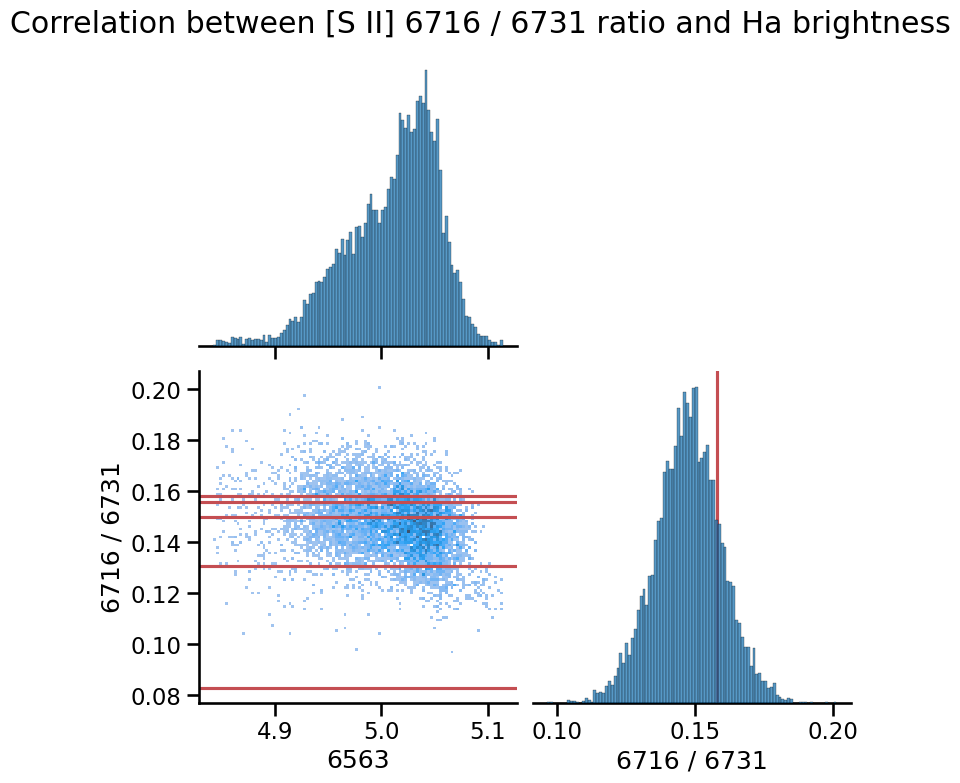

In [48]:
xslice, yslice = slice(230, 300), slice(144, 245)

n = 1

imx = imha[yslice, xslice].rebin(n)
imy = im6716[yslice, xslice].rebin(n) / im6731[yslice, xslice].rebin(n)

m = (imy.data > 1.1) & (imy.data < 2)
m = m & (imx.data < 1e6)
m = m & ~imx.mask & ~imy.mask
df = pd.DataFrame(
    {
        "6563": np.log10(imx.data[m]),
        "6716 / 6731": np.log10(imy.data[m]),
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(
        weights=imx.data[m],
        bins=100,
    ),
    diag_kws=dict(
        weights=imx.data[m],
        bins=100,
    ),
)
g.axes[1, 1].axvline(np.log10(Rgrid[0]), color="r")
for R in Rgrid[:-1]:
    g.axes[1, 0].axhline(np.log10(R), color="r")

g.fig.suptitle("Correlation between [S II] 6716 / 6731 ratio and Ha brightness")

Text(0.5, 0.98, 'Correlation between [S II] 6716 / 6731 ratio and Ha brightness')

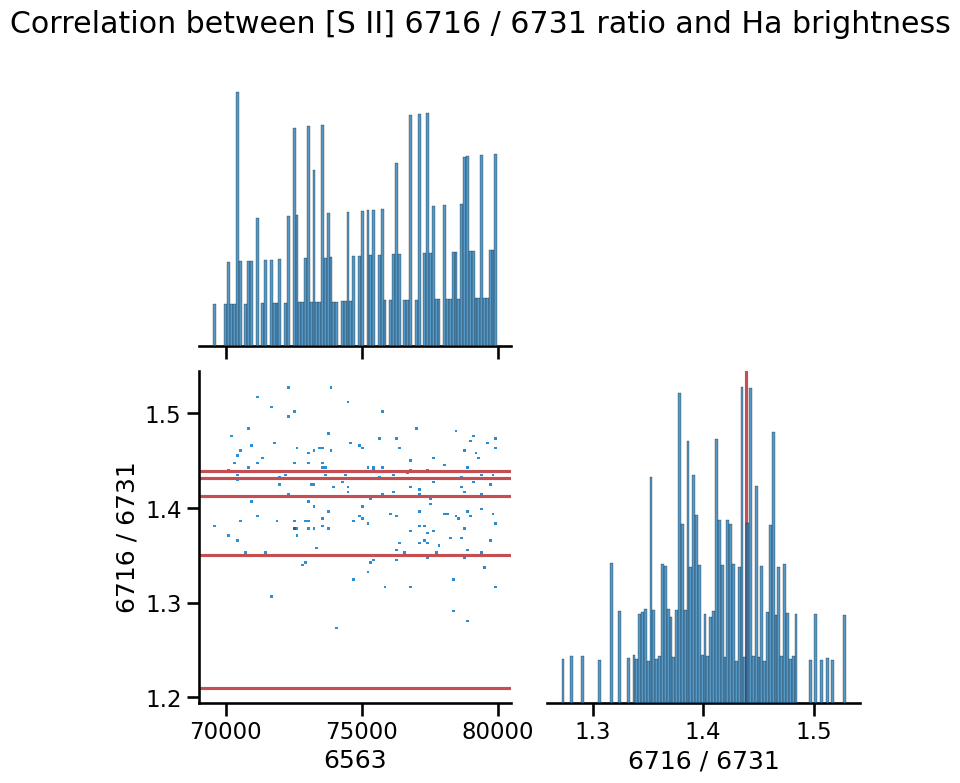

In [49]:
xslice, yslice = slice(230, 300), slice(144, 245)

n = 1

imx = imha[yslice, xslice].rebin(n)
imy = im6716[yslice, xslice].rebin(n) / im6731[yslice, xslice].rebin(n)

m = (imy.data > 1.1) & (imy.data < 2)
m = m & (imx.data < 80000)
m = m & ~imx.mask & ~imy.mask
df = pd.DataFrame(
    {
        "6563": imx.data[m],
        "6716 / 6731": imy.data[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(
        weights=imx.data[m],
        bins=100,
    ),
    diag_kws=dict(
        weights=imx.data[m],
        bins=100,
    ),
)
g.axes[1, 1].axvline(Rgrid[0], color="r")
for R in Rgrid[:-1]:
    g.axes[1, 0].axhline(R, color="r")

g.fig.suptitle("Correlation between [S II] 6716 / 6731 ratio and Ha brightness")

So, in the bow shock region, we see ratios as low as 1.3 in the brightest parts, but these are globule surfaces.  The bulk of the emission has around 1.4

In [314]:
s2.getTemDen([1.44, 1.4, 1.3, 0.8], tem=10200, wave1=6716, wave2=6731)

array([  12.68961003,   50.43532683,  157.53754256, 1605.85929962])

So the density is about 50 +/- 30 pcc in the diffuse gas.  We get ten times higher density in the case of Source E, which has a ratio as low as 0.8

### Make a map of [S II] density

In [345]:
r_s2_grid = np.linspace(0.5, 1.44, 1001)
n_s2_grid = s2.getTemDen(r_s2_grid, tem=13200.0, wave1=6716, wave2=6731)

In [346]:
n_s2_grid

array([1.43860000e+04, 1.41917435e+04, 1.40424705e+04, ...,
       3.56224789e+00, 1.88739182e+00, 1.00000000e+00])

In [347]:
fixmask = im6716.mask | (ew6716.data < 1.0) 
# fixmask[90:97, 147:152] = True
# fixmask[79:86, 191:197] = True


im_n_sii = im6716.clone(data_init=np.empty)
im_n_sii.mask = fixmask
trim_edges(im_n_sii, 10)
im_n_sii.data[~fixmask] = np.interp(
    im6716.data[~fixmask] / im6731.data[~fixmask],
    r_s2_grid,
    n_s2_grid,
    left=np.nan,
    right=np.nan,
)
im_n_sii.mask = im_n_sii.mask | ~np.isfinite(im_n_sii.data)

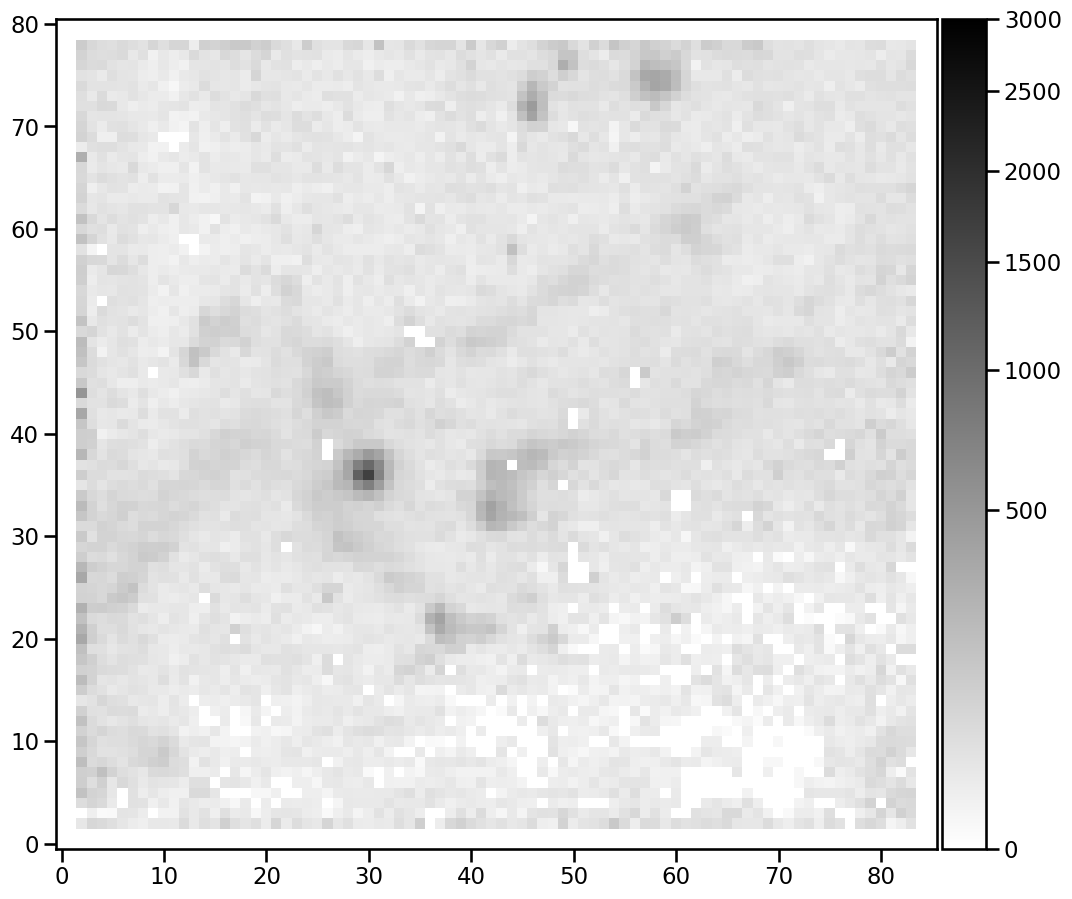

In [348]:
fig, ax = plt.subplots(figsize=(12, 12))
im_n_sii.rebin(4).plot(colorbar="v", cmap="gray_r", scale="sqrt", vmin=0.0, vmax=3000.0)

This seems to be good enough in some of the diffuse regions. although it is way to noisy in the faint parts.

In [349]:
im_n_sii.write(str(datadir) + "/ngc346-ZZ-N-sii.fits", savemask="nan")

In [350]:
im_T_siii = Image(str(datadir / "ngc346-ZZ-T-siii.fits"))
imhb = Image(str(datadir / "ngc346-ZZ-hi-4861-correct.fits"))

Text(0.5, 0.98, 'Temperature vs Density')

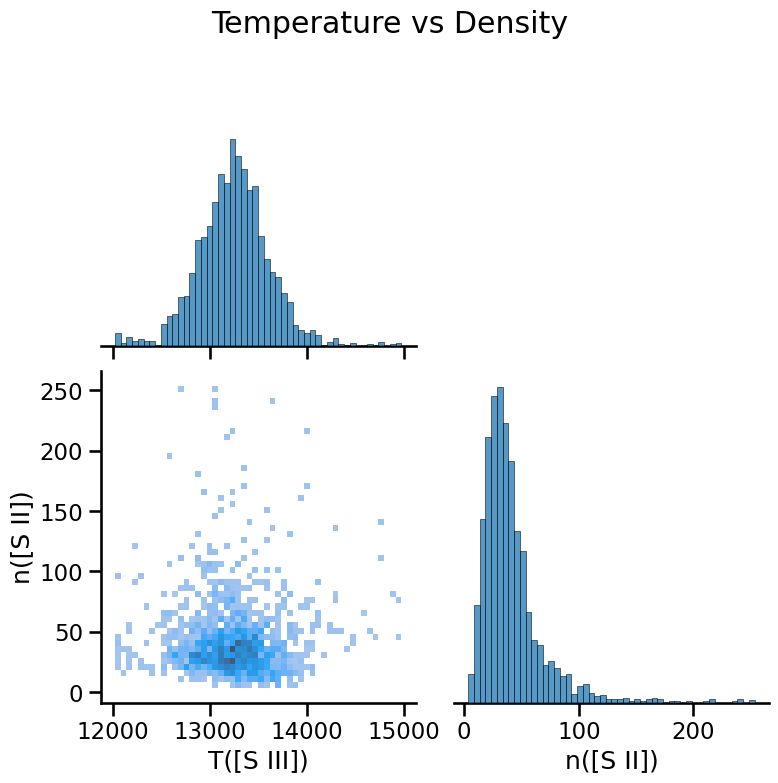

In [351]:
n = 8
imx = im_T_siii.rebin(n)
imy = im_n_sii.rebin(n)
imz = imhb.rebin(n)

m = ~imx.mask & ~imy.mask
m = m & (imx.data > 12000) & (imx.data < 15000)
m = m & (imy.data > 0) & (imy.data < 300)
df = pd.DataFrame(
    {
        "T([S III])": imx.data[m],
        "n([S II])": imy.data[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(
        weights=imz.data[m],
        bins=50,
    ),
    diag_kws=dict(
        weights=imz.data[m],
        bins=50,
    ),
)
g.fig.suptitle("Temperature vs Density")

So there is a slight anti-correlation between density and temperature for the bulk of the points. 

There is a high-density tail to the distribution, but no corresponding low-density tail. Perhaps that is just because of the log normal distribution

## Look at the histrograms of density, temperature, and brightness

### Temperature histogram

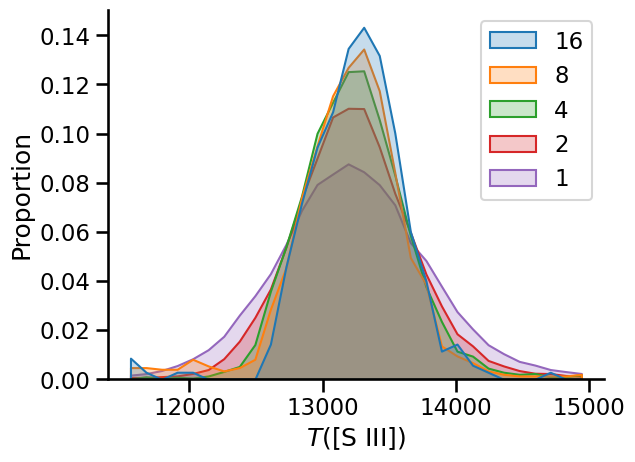

In [352]:
def get_all_T(n):
    _imT = im_T_siii.rebin(n)
    T_siii = _imT.data[~_imT.mask]
    return T_siii
xmin, xmax = 11500, 15000
binnings = [1, 2, 4, 8, 16]
Tdict = {_n: get_all_T(_n) for _n in binnings}
g = sns.histplot(
    Tdict, 
    bins=30, 
    binrange=[xmin, xmax], 
    stat="proportion", 
    common_norm=False, 
    multiple="layer",
    hue_order=binnings[::-1],
    element="poly",
).set_xlabel("$T$([S III])")
sns.despine()

The temperature I had already done in ZZ-01-01-B notebook, but just for the bow shock region. Here I am doing it for the whole nebula

In [353]:
for _n, _T in Tdict.items():
    print(f"{_n}: {np.mean(_T)/1000:.2f} +/- {np.std(_T)/1000:.2f}")


1: 12.71 +/- 2.27
2: 12.65 +/- 2.34
4: 12.58 +/- 2.30
8: 12.46 +/- 2.36
16: 12.65 +/- 1.47


So those statistics are very weird - the mean is way too low and the standard deviation is way too high. They must be affected by outliers.  So we will repeat it with sigma clipping:

In [354]:
from astropy.stats import SigmaClippedStats
for _n, _T in Tdict.items():
    stats = SigmaClippedStats(_T/1000)
    print(f"{_n}: {stats.mean():.2f} +/- {stats.std():.2f}")


1: 13.22 +/- 0.55
2: 13.22 +/- 0.42
4: 13.22 +/- 0.36
8: 13.22 +/- 0.35
16: 13.26 +/- 0.32


This is much better. The mean temperature is nearly identical to in the bow shock region. The std is somewhat higher. We can work out the POS t-squared:

In [355]:
print("t^2 =", (0.36/13.22)**2)
print("sigma_{T/T_0} = ", 0.36/13.22) 

t^2 = 0.0007415528207616479
sigma_{T/T_0} =  0.02723146747352496


### Density histogram

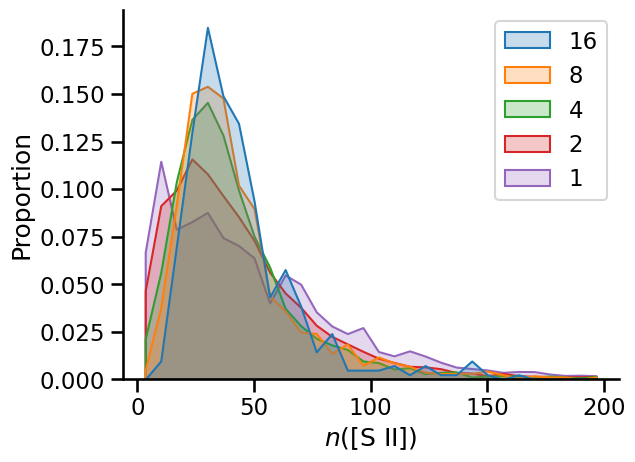

In [356]:
def get_all_n(n):
    _imn = im_n_sii.rebin(n)
    n_sii = _imn.data[~_imn.mask]
    return n_sii
xmin, xmax = 0, 200
binnings = [1, 2, 4, 8, 16]
ndict = {_n: get_all_n(_n) for _n in binnings}
g = sns.histplot(
    ndict, 
    bins=30, 
    binrange=[xmin, xmax], 
    stat="proportion", 
    common_norm=False, 
    multiple="layer",
    hue_order=binnings[::-1],
    element="poly",
).set_xlabel("$n$([S II])")
sns.despine()

In [357]:
for _n, _dens in ndict.items():
    print(f"{_n}: {np.mean(_dens):.2f} +/- {np.std(_dens):.2f}")


1: 56.23 +/- 72.50
2: 48.04 +/- 59.02
4: 45.52 +/- 51.51
8: 46.10 +/- 44.72
16: 46.31 +/- 35.73


Again, the raw statistics seem affected by outliers, so we do the sigma clipping. 

In [358]:
for _n, _dens in ndict.items():
    stats = SigmaClippedStats(_dens)
    print(f"{_n}: {stats.mean():.2f} +/- {stats.std():.2f}")


1: 44.35 +/- 31.85
2: 38.50 +/- 24.01
4: 36.80 +/- 19.09
8: 36.80 +/- 16.75
16: 39.72 +/- 16.38


This looks a lot more reasonable. The mean is stable at about 40 pcc and the std is dominated by noise for low binnings, but then stabilises for binning of 4 or more, getting a sigma of about 0.5 times the mean. 

In [359]:
print("sigma_{n/n_0} = ", 18.27/39.97) 

sigma_{n/n_0} =  0.45709281961471104


### Log-normal distribution

In [360]:
def lognormal(x, x0=1.0, std=1.0):
    fac = 1 + (std / x0)**2
    sigma = np.sqrt(np.log(fac))
    mu = np.log(x0 / np.sqrt(fac))
    Z = (np.log(x) - mu) / sigma
    return np.exp(-0.5 * Z ** 2) / (x * np.sqrt(2 * np.pi * np.log(fac)))

We have to use that mean and rms width of the gaussian distribution of ln(x) is given by 
$$
\mu_{\ln x} = \ln \left( x_0 / \sqrt{1 + \sigma^2_{x/x_0}} \right)
$$
$$
\sigma^2_{\ln x} = \ln \left( 1 + \sigma^2_{x/x_0} \right)
$$
Also note the extra factor of $1/x$ due to the conversion from $d x$ to $d \ln x$

/var/folders/0q/3pcjvc3n6sn2wk6g8ck6ry300000gn/T/ipykernel_59855/2067691617.py:5: RuntimeWarning: divide by zero encountered in log
  Z = (np.log(x) - mu) / sigma
/var/folders/0q/3pcjvc3n6sn2wk6g8ck6ry300000gn/T/ipykernel_59855/2067691617.py:6: RuntimeWarning: invalid value encountered in divide
  return np.exp(-0.5 * Z ** 2) / (x * np.sqrt(2 * np.pi * np.log(fac)))


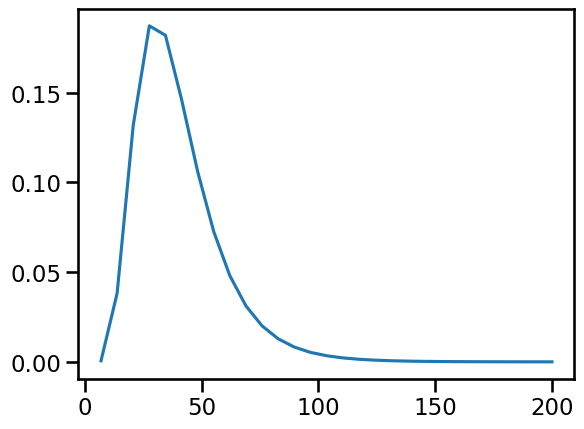

In [361]:
fig, ax = plt.subplots()
xx = np.linspace(0.0, 200.0, 30)
yy = lognormal(xx, x0=40, std=18.27)
ax.plot(xx, yy / np.nansum(yy))

In [362]:
m = np.isfinite(yy)
np.average(xx[m], weights=yy[m])

39.990469093483235

Now we can compare the n=4 result with the log-normal curve

In [363]:
ndict[4]

masked_array(data=[28.022701190186627, 76.90375592354152,
                   65.7410241351054, ..., 24.768673905077144,
                   26.615031356630084, 34.966415978862386],
             mask=[False, False, False, ..., False, False, False],
       fill_value=1e+20)

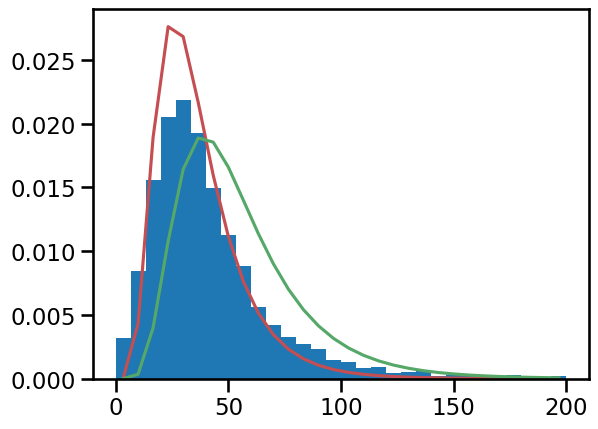

In [364]:
densities = ndict[4]
stats = SigmaClippedStats(densities)
 
fig, ax = plt.subplots()
xmin, xmax = 0, 200
hist, edges, patches = ax.hist(densities, bins=30, range=[xmin, xmax], density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

dens_fit = lognormal(centers, x0=stats.mean(), std=stats.std())
ax.plot(centers, dens_fit, color="r")

dens_alt = lognormal(centers, x0=55, std=28)
ax.plot(centers, dens_alt, color="g")


The log-normal curve is a reasonable approximation, but the high density tail shows an excess.

So it looks like about 90% of the pixels follow the log-normal distribution, but that then there is 10% that has higher densities. Looking at the map above, it is clear that this corresponds to the globules and filaments.

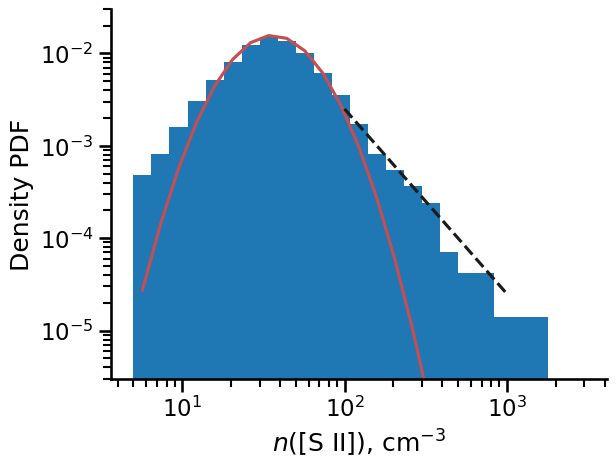

In [382]:
densities = ndict[4]
stats = SigmaClippedStats(densities)
 
fig, ax = plt.subplots()
xmin, xmax = 5, 3000
hist, edges = np.histogram(
    np.log10(densities), 
    bins=25, 
    range=[np.log10(xmin), np.log10(xmax)], 
)
centers = 0.5 * (edges[:-1] + edges[1:])

norm = np.trapz(hist, 10**centers)
ax.stairs(hist/norm, 10**edges, fill=True)

dens_fit = lognormal(10**centers, x0=54, std=30)
ax.plot(10**centers, 0.84 * dens_fit, color="r")
ax.plot([100, 1000], [2.5e-3, 2.5e-5], color="k", ls="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(3e-6, 3e-2)
ax.set_xlabel(r"$n$([S II]), cm$^{-3}$")
ax.set_ylabel("Density PDF")
sns.despine()
fig.savefig(figdir / "ngc346-ZZ-density.pdf", bbox_inches="tight")

Plotting on a log scale shows that there is a power law tail.  I fit a log-normal to the low-density part, but with mean and width that I fixed by hand. And scaled it by 0.85

So 15% of the area of the nebula is the high-density tail of the PDF. **This does not seem to be true, see below** Perhaps there is an excess to low density too, although it does not look so large in the PDF. Also, the density measurements are extremely unreliable on the low-density side, so are probably dominated by noise

/var/folders/0q/3pcjvc3n6sn2wk6g8ck6ry300000gn/T/ipykernel_59855/2919740707.py:12: RuntimeWarning: divide by zero encountered in log10
  np.log10(densities),


Text(0, 0.5, 'H$\\alpha$-weighted Density PDF')

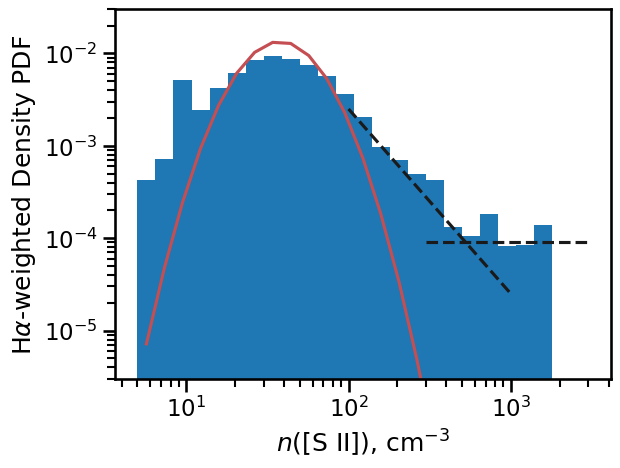

In [379]:
n = 4
m = ew6716.rebin(n).data > 1.0
densities = im_n_sii.rebin(n).data[m]
weights = imha.rebin(n).data[m]
# weights = im6716.rebin(n).data[m]

stats = SigmaClippedStats(densities)
 
fig, ax = plt.subplots()
xmin, xmax = 5, 3000
hist, edges = np.histogram(
    np.log10(densities), 
    weights=weights,
    bins=25, 
    range=[np.log10(xmin), np.log10(xmax)], 
)
centers = 0.5 * (edges[:-1] + edges[1:])

norm = np.trapz(hist, 10**centers)
ax.stairs(hist/norm, 10**edges, fill=True)

dens_fit = lognormal(10**centers, x0=54, std=28)
ax.plot(10**centers, 0.7 * dens_fit, color="r")
ax.plot([100, 1000], [2.5e-3, 2.5e-5], color="k", ls="--")
ax.plot([300, 3000], [9e-5, 9e-5], color="k", ls="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(3e-6, 3e-2)
ax.set_xlabel(r"$n$([S II]), cm$^{-3}$")
ax.set_ylabel(r"H$\alpha$-weighted Density PDF")

Look at the fractions of total flux and total are that come from the high-density pixels

In [376]:
n = 4
m = im_n_sii.rebin(n).mask | imha.rebin(n).mask
m |= ew6716.rebin(n).data < 1
m100 = (im_n_sii.rebin(n).data > 100) & ~m
m400 = (im_n_sii.rebin(n).data > 400) & ~m
efrac100 = np.sum(imha.rebin(n).data[m100]) / np.sum(imha.rebin(n).data[~m])
efrac400 = np.sum(imha.rebin(n).data[m400]) / np.sum(imha.rebin(n).data[~m])
efrac100, efrac400

(0.06940308620290508, 0.00723557581599674)

In [377]:
total_pix = np.sum(~m)
np.sum(m100) / total_pix, np.sum(m400) / total_pix

(0.055165496489468405, 0.0021731862253426947)

In [378]:
[np.sum(_) for _ in (m, ~m, m100, m400)]

[984, 5982, 330, 13]

So we do not have much difference between the area-weighted and flux-weighted fractions. Also, 
we get a larger fraction with n=1, but that is because we have a lot of pixels that are masked out because they are in the low-density limit. 

So, I think that 6 to 7% of the area is occupied by the high density filaments

### H alpha brightness histogram

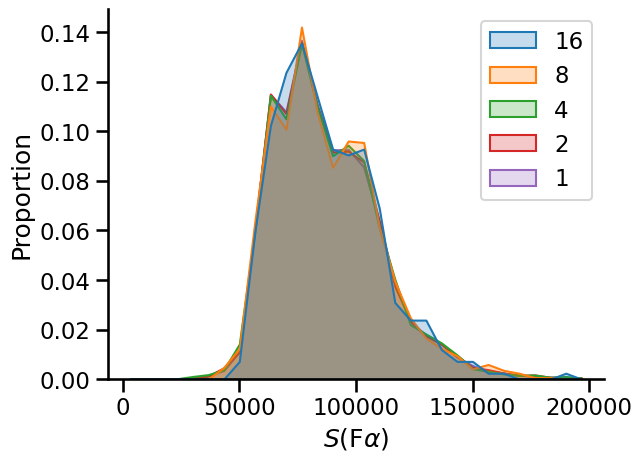

In [370]:
def get_all_ha(n):
    _im = imha.rebin(n)
    ha = _im.data[~_im.mask]
    return ha
xmin, xmax = 0, 2e5
binnings = [1, 2, 4, 8, 16]
hadict = {_n: get_all_ha(_n) for _n in binnings}
g = sns.histplot(
    hadict, 
    bins=30, 
    binrange=[xmin, xmax], 
    stat="proportion", 
    common_norm=False, 
    multiple="layer",
    hue_order=binnings[::-1],
    element="poly",
)
g.set_xlabel(r"$S$(F$\alpha$)")
sns.despine()

In [371]:
for _n, _ha in hadict.items():
    print(f"{_n}: {np.mean(_ha):.2f} +/- {np.std(_ha):.2f}")


1: 87843.68 +/- 26509.41
2: 87882.69 +/- 26493.58
4: 87830.15 +/- 26293.84
8: 88059.99 +/- 24548.20
16: 87625.31 +/- 21725.92


Again, the raw statistics seem affected by outliers, so we do the sigma clipping. 

In [372]:
for _n, _ha in hadict.items():
    stats = SigmaClippedStats(_ha)
    print(f"{_n}: {stats.mean():.2f} +/- {stats.std():.2f}")


1: 85975.22 +/- 20342.77
2: 85982.91 +/- 20427.62
4: 86051.80 +/- 20705.96
8: 85984.89 +/- 20079.38
16: 86577.58 +/- 19978.21


So only 20% to 25% sigma, which is much less than I had determined before. But maybe I had weighted them somehow

/var/folders/0q/3pcjvc3n6sn2wk6g8ck6ry300000gn/T/ipykernel_59855/55651429.py:7: RuntimeWarning: invalid value encountered in log10
  np.log10(brightnesses),


Text(0, 0.5, 'Brightness PDF')

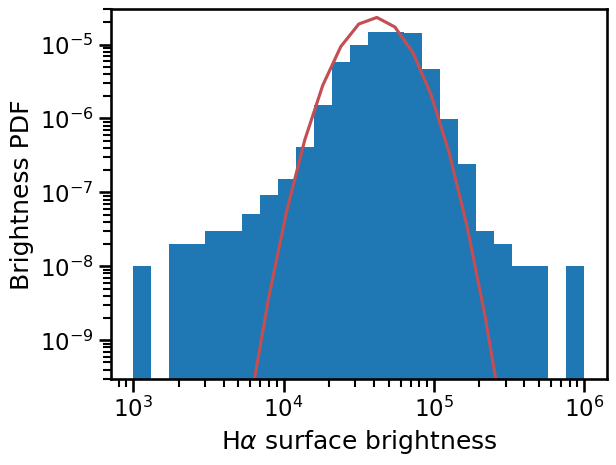

In [373]:
brightnesses = hadict[4] - 35000
stats = SigmaClippedStats(brightnesses)
 
fig, ax = plt.subplots()
xmin, xmax = 1e3, 1e6
hist, edges = np.histogram(
    np.log10(brightnesses), 
    bins=25, 
    range=[np.log10(xmin), np.log10(xmax)], 
)
centers = 0.5 * (edges[:-1] + edges[1:])

norm = np.trapz(hist, 10**centers)
ax.stairs(hist/norm, 10**edges, fill=True)

bright_fit = lognormal(10**centers, x0=stats.mean(), std=stats.std())
ax.plot(10**centers, bright_fit, color="r")
# ax.plot([100, 1000], [2.5e-3, 2.5e-5], color="k", ls="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(3e-10, 3e-5)
ax.set_xlabel(r"H$\alpha$ surface brightness")
ax.set_ylabel("Brightness PDF")

So this is totally dependent on where we put the zero point.